In [1]:
import pandas as pd
df = pd.read_csv("Merged_Ambreplayan.csv")

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 2002-08-11 08:00:00           8.487        0.0304           22.291615   
1 2002-08-15 08:00:00           9.110        0.0302           23.770541   
2 2002-08-18 08:00:00          10.790        0.0052            4.847731   
3 2002-08-25 08:00:00           5.772        0.0176            8.777134   
4 2002-09-01 08:00:00           8.795        0.0244           18.541267   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0304                      0.258005                      22.291615  
1          0.0302                      0.275122                      23.770541  
2          0.0052                      0.056108                       4.847731  
3          0.0176                      0.101587                       8.777134  
4          0.0244                      0.214598                      18.541267  

Comparison of user's Se

C:\Users\91824\AppData\Local\Temp\ipykernel_21960\1948502146.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sediment_per_class = df_analytical.groupby('Discharge_Class')['Sediment_tonne_day_used'].sum().reset_index()
C:\Users\91824\AppData\Local\Temp\ipykernel_21960\1948502146.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_per_class = df_analytical.groupby('Discharge_Class').size().reset_index(name='Count')



Effective Discharge (Qeff) by Magnitude-Frequency Approach:
Representative Discharge: 16.47 m³/s
Corresponding Effectiveness (E(Q)): 6.62

--- Analytical Approaches ---
Log-normal distribution parameters for discharge: s=0.8052, loc=0.0000, scale=7.2113

Sediment Rating Curve (Qs = aQ^b) parameters:
a (exp(intercept)): 0.0098
b (slope): 1.1594
R-squared: 0.6988

Effective Discharge (Qeff) by Analytical Approach:
Qeff: 7.77 m³/s
Corresponding Effectiveness (E(Q)): 0.0067


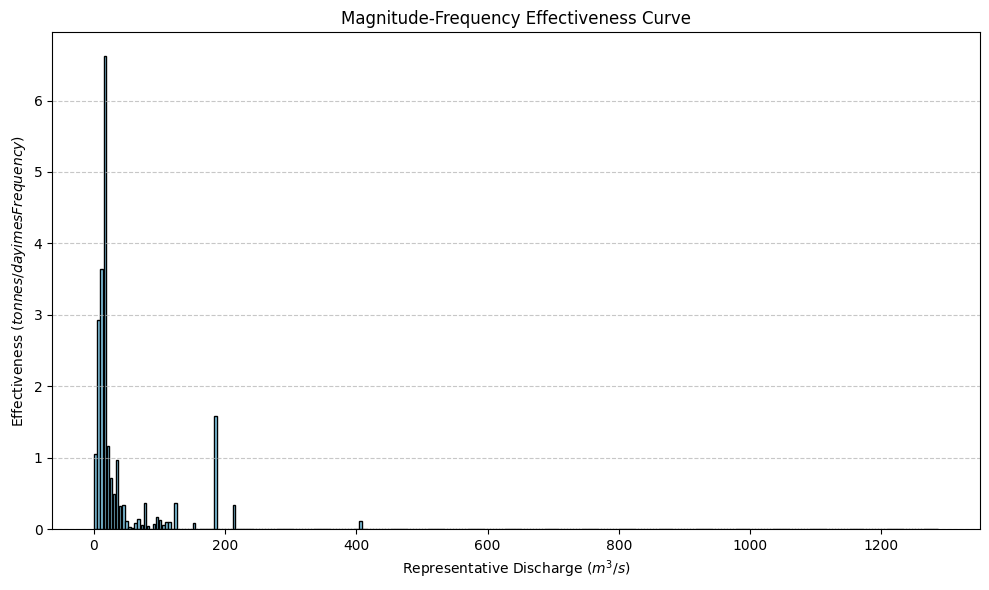

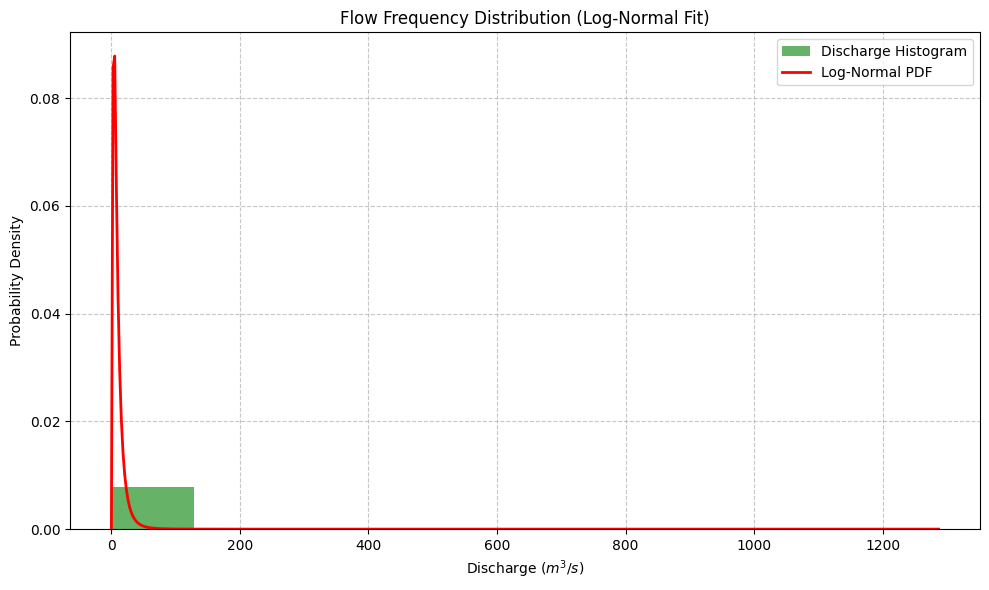

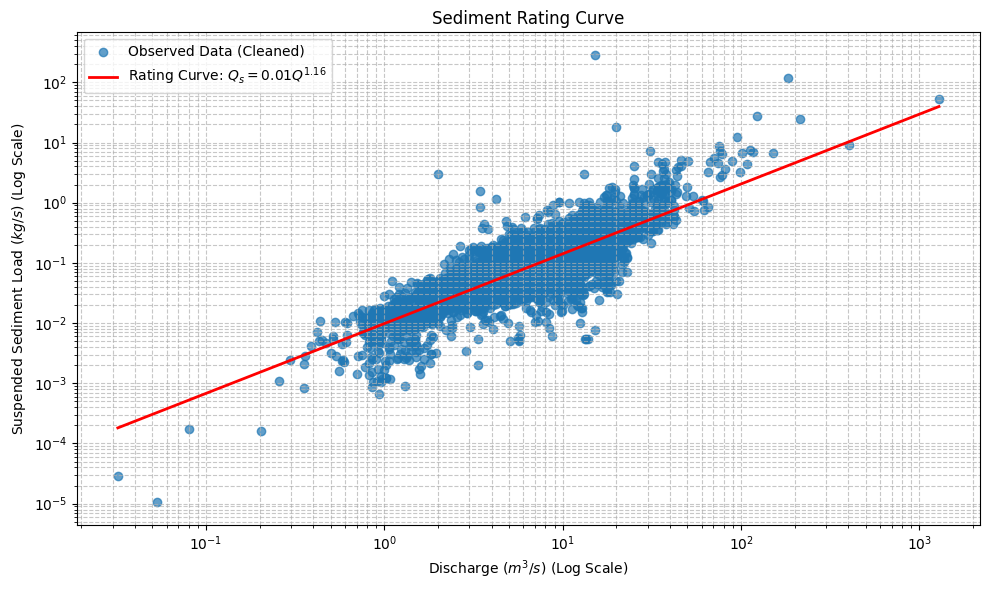

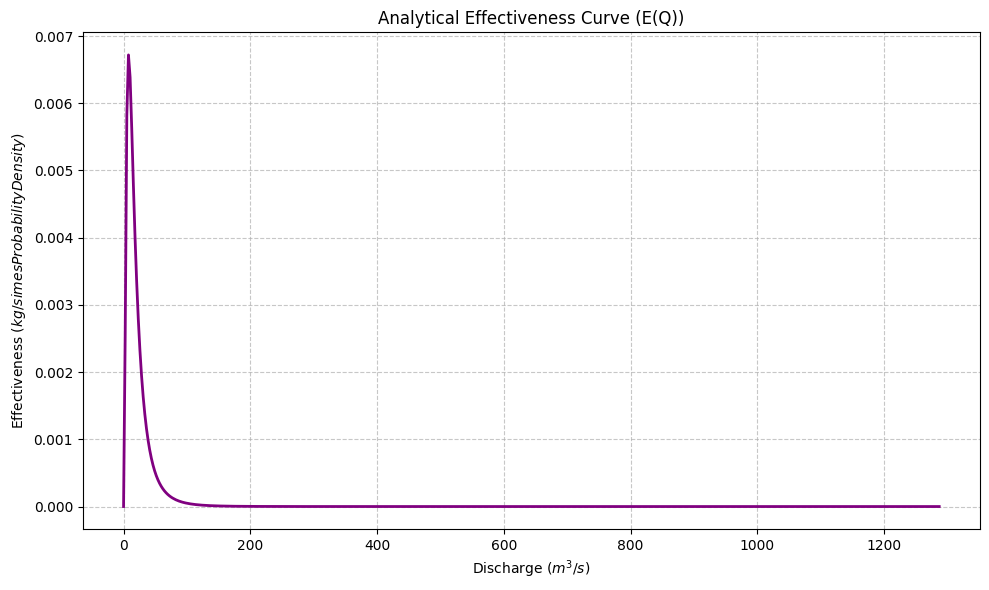

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

# --- Data Preparation (Ensure these steps run first and create the necessary columns) ---
# Convert 'Timestamp' to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())
print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Check if the calculated values are close to the user's provided 'Sediment_tonne_day'
# Using np.isclose to handle potential floating point differences
if np.all(np.isclose(df['Sediment_tonne_day'], df['Calculated_Sediment_tonne_day'], rtol=1e-3, equal_nan=True)):
    print("\nCalculated 'Sediment_tonne_day' matches the user-provided column (within a small tolerance and NaN-aware).")
    df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']
else:
    print("\nCalculated 'Sediment_tonne_day' does NOT exactly match the user-provided column.")
    print("Please verify your initial 'Sediment_tonne_day' calculation logic if this discrepancy is significant.")
    df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']


# --- CRITICAL DATA CLEANING STEP FOR ANALYTICAL AND HISTOGRAM APPROACHES ---
# Create a copy of the DataFrame to perform cleaning for analytical methods
df_analytical = df.copy()

# 1. Drop rows where 'Discharge_m3_s' or 'Suspended_Sediment_Load_kg_s' are NaN
#    These are the primary columns for the analytical fits.
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])

# 2. Filter out rows where 'Discharge_m3_s' or 'Suspended_Sediment_Load_kg_s' are <= 0
#    Logarithms are undefined for non-positive numbers (log(0) is -inf, log(negative) is NaN).
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

# Check if there's enough data left after cleaning for analytical methods
if df_analytical.empty:
    print("\nWARNING: No valid data left for Analytical Approaches after cleaning (due to NaNs or non-positive values). Skipping analytical fits.")
    # Set a flag to skip analytical section if no data
    skip_analytical = True
else:
    skip_analytical = False

# --- Magnitude-Frequency Histogram Approach ---
# Use df_analytical for this section as well to work with clean data
# If you prefer to use less strictly cleaned data for histogram (e.g., allow zeros),
# you would create a separate df_histogram here with different cleaning rules.
# For now, we'll use df_analytical for consistency.

if not df_analytical.empty: # Only proceed if df_analytical is not empty
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1. Define Discharge Classes
    # Calculate standard deviation of Discharge_m3_s from the cleaned data
    discharge_std = df_analytical['Discharge_m3_s'].std()

    # Handle cases where std is 0 (e.g., all discharge values are the same)
    if discharge_std == 0:
        class_interval_size = 1.0 # Use a default small interval if no variation
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # Determine bins for the histogram
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    # Create bins that cover the full range of discharge values
    # Add a small epsilon to max_discharge to ensure max value is included if right=False
    # Handle case where min_discharge == max_discharge (e.g., only one unique value)
    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2] # Create a bin that covers the single value
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # If there are too few bins (due to small dataset), adjust for better visualization
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2: num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0] # Recalculate based on new bins
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        # If only one or zero data points, bins might be trivial, but we'll try to make it work
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else: # df_analytical is empty here, handled by outer if
            bins = [] # No bins if no data

    if len(bins) > 1: # Ensure there are at least two bin edges to proceed
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 2. Compute Total Sediment Load per Class
        df_analytical['Discharge_Class'] = pd.cut(df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False)

        all_categories = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {category: (category.left + category.right) / 2 for category in all_categories}

        sediment_per_class = df_analytical.groupby('Discharge_Class')['Sediment_tonne_day_used'].sum().reset_index()
        sediment_per_class['Representative_Discharge'] = sediment_per_class['Discharge_Class'].map(midpoint_map)

        discharge_frequency_per_class = df_analytical['Discharge_Class'].value_counts(normalize=True).sort_index().reset_index()
        discharge_frequency_per_class.columns = ['Discharge_Class', 'Frequency']
        discharge_frequency_per_class['Representative_Discharge'] = discharge_frequency_per_class['Discharge_Class'].map(midpoint_map)

        effectiveness_data = pd.merge(sediment_per_class, discharge_frequency_per_class, on=['Discharge_Class', 'Representative_Discharge'], how='outer')

        effectiveness_data['Sediment_tonne_day_used'] = effectiveness_data['Sediment_tonne_day_used'].fillna(0)
        effectiveness_data['Frequency'] = effectiveness_data['Frequency'].fillna(0)

        count_per_class = df_analytical.groupby('Discharge_Class').size().reset_index(name='Count')
        effectiveness_data = pd.merge(effectiveness_data, count_per_class, on='Discharge_Class', how='left').fillna({'Count': 0})

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = effectiveness_data.apply(
            lambda row: row['Sediment_tonne_day_used'] / row['Count'] if row['Count'] > 0 else 0,
            axis=1
        )

        effectiveness_data['E_Q'] = effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_tonne_day_used', 'Frequency', 'Count', 'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 3. Construct the Histogram (Effectiveness Curve)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty: # Check if there's data to plot
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'], width=class_interval_size * 0.8, color='skyblue', edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 4. Identify Effective Discharge (Qeff)
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = effectiveness_data.loc[effectiveness_data['E_Q'].idxmax()]
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency Approach:")
            print(f"Representative Discharge: {qeff_magnitude_frequency['Representative_Discharge']:.2f} m³/s")
            print(f"Corresponding Effectiveness (E(Q)): {qeff_magnitude_frequency['E_Q']:.2f}")
        else:
            print("\nCould not determine Effective Discharge by Magnitude-Frequency Approach: No meaningful effectiveness found (perhaps all E_Q are 0 or NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")


# --- Analytical Approaches (using df_analytical) ---

if not skip_analytical: # Only proceed if df_analytical is not empty and not skipped
    print("\n--- Analytical Approaches ---")

    # 1. Model Flow Frequency Distribution (f(Q))
    # Fit a log-normal distribution to discharge data from df_analytical
    s, loc, scale = lognorm.fit(df_analytical['Discharge_m3_s'], floc=0) # Use df_analytical!

    print(f"Log-normal distribution parameters for discharge: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

    # Generate a range of discharge values for plotting the PDF
    # Use min/max from df_analytical for accurate plotting range
    q_range = np.linspace(df_analytical['Discharge_m3_s'].min(), df_analytical['Discharge_m3_s'].max(), 500)
    pdf_q = lognorm.pdf(q_range, s, loc, scale)

    plt.figure(figsize=(10, 6))
    plt.hist(df_analytical['Discharge_m3_s'], bins=10, density=True, alpha=0.6, color='g', label='Discharge Histogram')
    plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
    plt.xlabel('Discharge ($m^3/s$)')
    plt.ylabel('Probability Density')
    plt.title('Flow Frequency Distribution (Log-Normal Fit)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('flow_frequency_distribution.png')

    # 2. Model Sediment Rating Curve (S(Q) or Qs = aQ^b)
    # Perform linear regression on log-transformed data from df_analytical
    log_discharge = np.log(df_analytical['Discharge_m3_s'])
    log_sediment_load = np.log(df_analytical['Suspended_Sediment_Load_kg_s'])

    slope, intercept, r_value, p_value, std_err = linregress(log_discharge, log_sediment_load)

    # Qs = aQ^b, where a = exp(intercept), b = slope
    a_coef = np.exp(intercept)
    b_exp = slope

    print(f"\nSediment Rating Curve (Qs = aQ^b) parameters:")
    print(f"a (exp(intercept)): {a_coef:.4f}")
    print(f"b (slope): {b_exp:.4f}")
    print(f"R-squared: {r_value**2:.4f}")

    # Generate sediment rating curve for plotting
    qs_rating_curve = a_coef * (q_range ** b_exp) # Use q_range from pdf_q

    plt.figure(figsize=(10, 6))
    plt.scatter(df_analytical['Discharge_m3_s'], df_analytical['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed Data (Cleaned)')
    plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating Curve: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Discharge ($m^3/s$) (Log Scale)')
    plt.ylabel('Suspended Sediment Load ($kg/s$) (Log Scale)')
    plt.title('Sediment Rating Curve')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig('sediment_rating_curve.png')

    # 3. Derive the Effectiveness Curve (E(Q) = f(Q) * S(Q))
    effectiveness_curve_analytical = pdf_q * qs_rating_curve

    plt.figure(figsize=(10, 6))
    plt.plot(q_range, effectiveness_curve_analytical, 'purple', lw=2)
    plt.xlabel('Discharge ($m^3/s$)')
    plt.ylabel('Effectiveness ($kg/s \times Probability Density$)')
    plt.title('Analytical Effectiveness Curve (E(Q))')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('analytical_effectiveness_curve.png')

    # 4. Identify Effective Discharge (Qeff)
    if effectiveness_curve_analytical.size > 0:
        qeff_analytical_index = np.argmax(effectiveness_curve_analytical)
        qeff_analytical = q_range[qeff_analytical_index]
        max_e_q_analytical = effectiveness_curve_analytical[qeff_analytical_index]

        print(f"\nEffective Discharge (Qeff) by Analytical Approach:")
        print(f"Qeff: {qeff_analytical:.2f} m³/s")
        print(f"Corresponding Effectiveness (E(Q)): {max_e_q_analytical:.4f}")
    else:
        print("\nCould not determine Effective Discharge by Analytical Approach: Effectiveness curve is empty.")

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 2002-08-11 08:00:00           8.487        0.0304           22.291615   
1 2002-08-15 08:00:00           9.110        0.0302           23.770541   
2 2002-08-18 08:00:00          10.790        0.0052            4.847731   
3 2002-08-25 08:00:00           5.772        0.0176            8.777134   
4 2002-09-01 08:00:00           8.795        0.0244           18.541267   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0304                      0.258005                      22.291615  
1          0.0302                      0.275122                      23.770541  
2          0.0052                      0.056108                       4.847731  
3          0.0176                      0.101587                       8.777134  
4          0.0244                      0.214598                      18.541267  

Comparison of user's Se

AttributeError: 'Series' object has no attribute 'to_series'

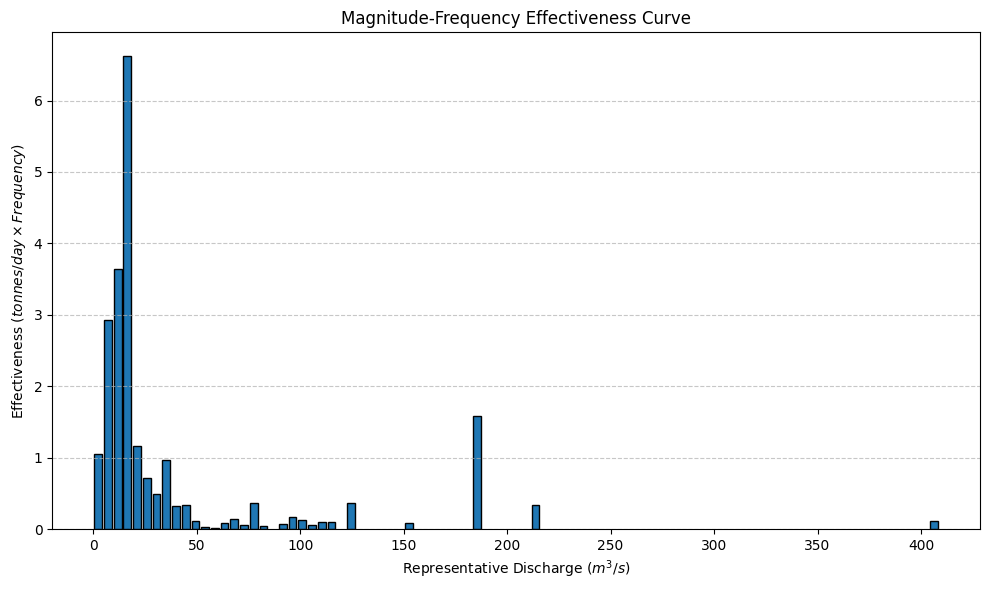

In [4]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Ambreplayan.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    counts = ts.to_series().groupby(ts.dt.year).count()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

if df_analytical.empty:
    print("\nWARNING: No valid data left for Analytical Approaches after cleaning. Skipping analytical fits.")
    skip_analytical = True
else:
    skip_analytical = False

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using lognormal + inferred samples/year
            N = infer_samples_per_year(df['Timestamp'])
            Q_1_5 = q_return_lognormal(s, loc, scale, T_years=1.5, samples_per_year=N)

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout(); plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout(); plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout(); plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 2002-08-11 08:00:00           8.487        0.0304           22.291615   
1 2002-08-15 08:00:00           9.110        0.0302           23.770541   
2 2002-08-18 08:00:00          10.790        0.0052            4.847731   
3 2002-08-25 08:00:00           5.772        0.0176            8.777134   
4 2002-09-01 08:00:00           8.795        0.0244           18.541267   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0304                      0.258005                      22.291615  
1          0.0302                      0.275122                      23.770541  
2          0.0052                      0.056108                       4.847731  
3          0.0176                      0.101587                       8.777134  
4          0.0244                      0.214598                      18.541267  

Comparison of user's Se

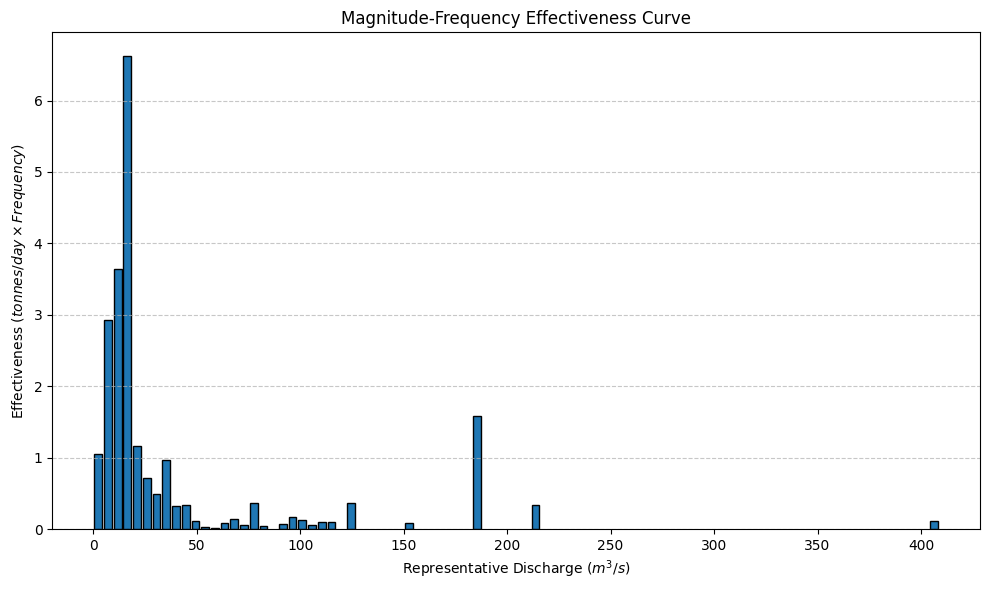

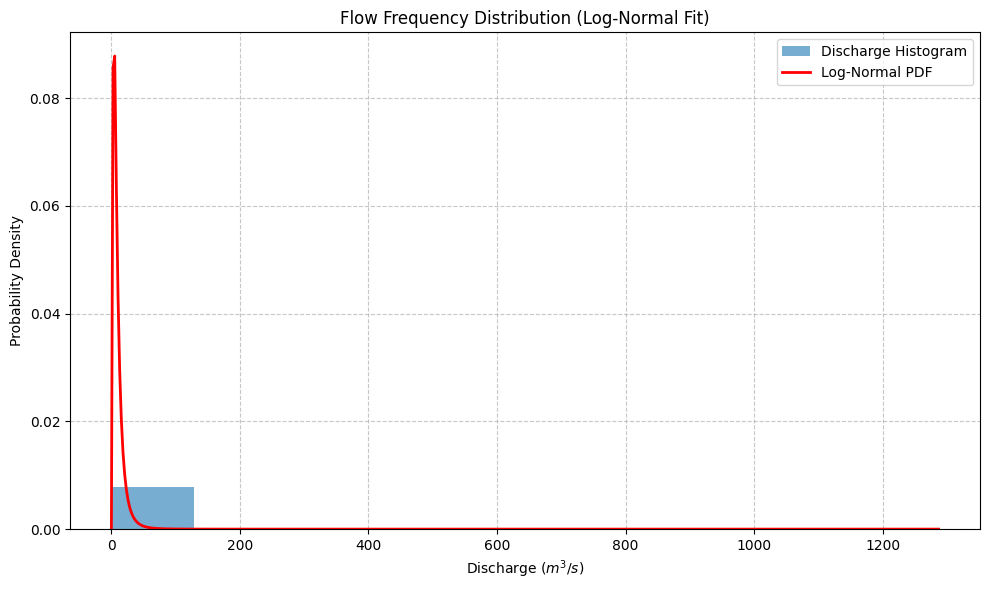

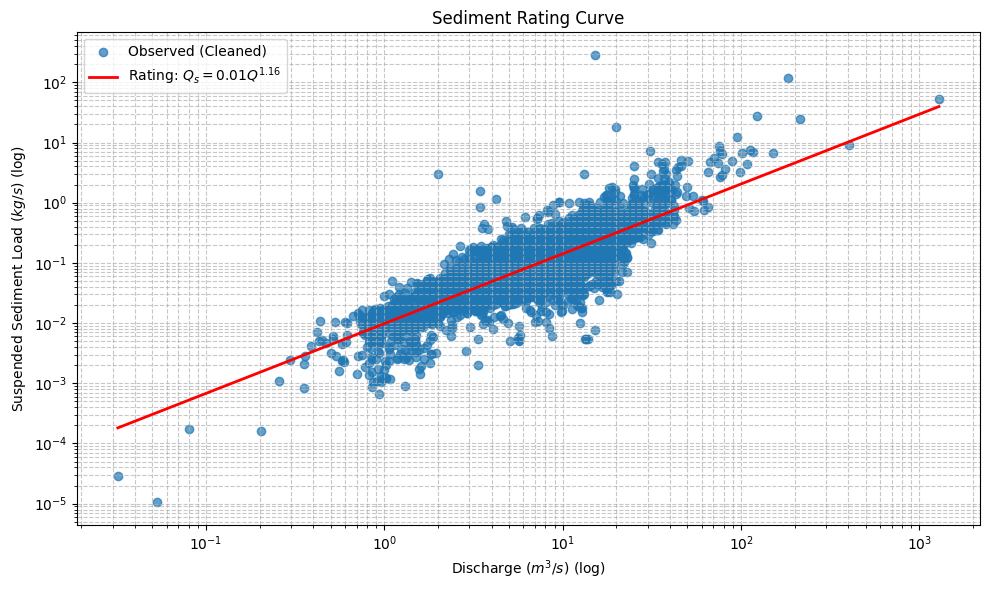

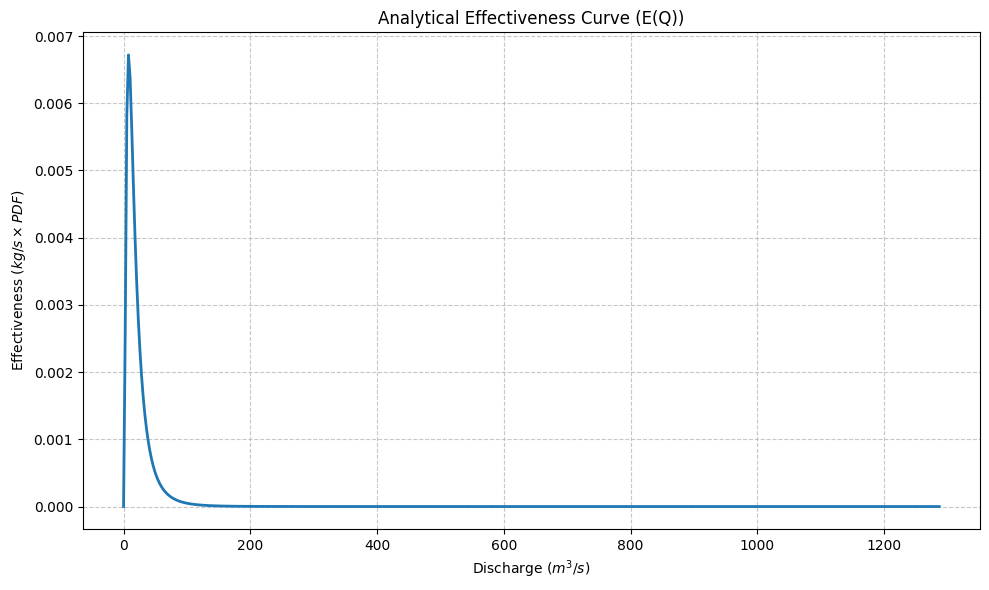

In [5]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Ambreplayan.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using lognormal + inferred samples/year
            N = infer_samples_per_year(df['Timestamp'])
            Q_1_5 = q_return_lognormal(s, loc, scale, T_years=1.5, samples_per_year=N)

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout(); plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout(); plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout(); plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)